In [ ]:
!wget -r -N -c -np https://physionet.org/files/ptb-xl/1.0.3/records100/

Streaming output truncated to the last 5000 lines.
Length: 24000 (23K) [application/octet-stream]
Saving to: ‘physionet.org/files/ptb-xl/1.0.3/records100/21000/21588_lr.dat’

physionet.org/files 100%[===================>]  23.44K  --.-KB/s    in 0.03s   

2026-03-18 09:27:54 (845 KB/s) - ‘physionet.org/files/ptb-xl/1.0.3/records100/21000/21588_lr.dat’ saved [24000/24000]

--2026-03-18 09:27:54--  https://physionet.org/files/ptb-xl/1.0.3/records100/21000/21588_lr.hea
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 606 [text/plain]
Saving to: ‘physionet.org/files/ptb-xl/1.0.3/records100/21000/21588_lr.hea’

physionet.org/files 100%[===================>]     606  --.-KB/s    in 0s      

2026-03-18 09:27:54 (202 MB/s) - ‘physionet.org/files/ptb-xl/1.0.3/records100/21000/21588_lr.hea’ saved [606/606]

--2026-03-18 09:27:54--  https://physionet.org/files/ptb-xl/1.0.3/records100/21000/21589_lr.dat
Reusing existing connection to physion

In [ ]:
!pip install wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 38.1 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.1 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.1 which is incompatible.
db-dtypes 1.5.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.1 which is incompatible.


In [11]:
import os
print(os.listdir('/content/physionet.org/files/ptb-xl/1.0.3/'))

['ptbxl_database.csv', 'records100', 'scp_statements.csv']


In [ ]:
!wget https://physionet.org/files/ptb-xl/1.0.3/ptbxl_database.csv -P /content/physionet.org/files/ptb-xl/1.0.3/
!wget https://physionet.org/files/ptb-xl/1.0.3/scp_statements.csv -P /content/physionet.org/files/ptb-xl/1.0.3/

--2026-03-18 09:49:11--  https://physionet.org/files/ptb-xl/1.0.3/ptbxl_database.csv
Resolving physionet.org (physionet.org)... 18.18.42.54
Connecting to physionet.org (physionet.org)|18.18.42.54|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6594879 (6.3M) [text/plain]
Saving to: ‘/content/physionet.org/files/ptb-xl/1.0.3/ptbxl_database.csv’

ptbxl_database.csv  100%[===================>]   6.29M   237KB/s    in 27s     

2026-03-18 09:49:38 (236 KB/s) - ‘/content/physionet.org/files/ptb-xl/1.0.3/ptbxl_database.csv’ saved [6594879/6594879]

--2026-03-18 09:49:39--  https://physionet.org/files/ptb-xl/1.0.3/scp_statements.csv
Resolving physionet.org (physionet.org)... 18.18.42.54
Connecting to physionet.org (physionet.org)|18.18.42.54|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9720 (9.5K) [text/plain]
Saving to: ‘/content/physionet.org/files/ptb-xl/1.0.3/scp_statements.csv’

scp_statements.csv  100%[===================>]   9.49K 

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb
import ast
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization, Flatten
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# New path
path = '/content/physionet.org/files/ptb-xl/1.0.3/'

# Load labels
Y = pd.read_csv(path + 'ptbxl_database.csv', index_col='ecg_id')
Y.scp_codes = Y.scp_codes.apply(ast.literal_eval)

print("Database loaded!")
print(f"Total records: {len(Y)}")

Database loaded!
Total records: 21799


In [7]:
# Get diagnostic labels
def get_label(y_dic):
    keys = list(y_dic.keys())
    if len(keys) > 0:
        return keys[0]
    return 'UNKNOWN'

Y['label'] = Y.scp_codes.apply(get_label)

# Keep top 5 classes
top_classes = ['NORM', 'IMI', 'ASMI', 'LVH', 'LAFB']
Y_filtered = Y[Y['label'].isin(top_classes)]

print(f"Filtered records: {len(Y_filtered)}")
print(Y_filtered['label'].value_counts())

Filtered records: 15612
label
NORM    9514
IMI     2317
ASMI    1879
LVH     1212
LAFB     690
Name: count, dtype: int64


In [8]:
def load_raw_data(df, path):
    data = []
    labels = []
    for idx, row in df.iterrows():
        try:
            signal, meta = wfdb.rdsamp(path + row.filename_lr)
            data.append(signal)
            labels.append(row.label)
        except:
            pass
    return np.array(data), np.array(labels)

X, y = load_raw_data(Y_filtered, '/content/physionet.org/files/ptb-xl/1.0.3/')
print(f"Signal shape: {X.shape}")
print(f"Labels shape: {y.shape}")

Signal shape: (15612, 1000, 12)
Labels shape: (15612,)


In [10]:
from sklearn.model_selection import train_test_split

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Train: {X_train.shape}")
print(f"Test: {X_test.shape}")

Train: (12489, 1000, 12)
Test: (3123, 1000, 12)


In [12]:
# Build 1D CNN + LSTM Model
model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(1000, 12)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(128, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(256, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    LSTM(128, return_sequences=False),
    Dropout(0.4),

    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(5, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 998, 64)        │         2,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 998, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 499, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 497, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 497, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 248, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 246, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 246, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 123, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 341,701 (1.30 MB)

 Trainable params: 340,805 (1.30 MB)

 Non-trainable params: 896 (3.50 KB)

In [13]:
early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, reduce_lr]
)
A
print("Training complete!")

Epoch 1/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 227s 565ms/step - accuracy: 0.7038 - loss: 0.8341 - val_accuracy: 0.7291 - val_loss: 0.7942 - learning_rate: 0.0010
Epoch 2/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 251s 538ms/step - accuracy: 0.7796 - loss: 0.6209 - val_accuracy: 0.7996 - val_loss: 0.5712 - learning_rate: 0.0010
Epoch 3/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 219s 560ms/step - accuracy: 0.8056 - loss: 0.5519 - val_accuracy: 0.8252 - val_loss: 0.4839 - learning_rate: 0.0010
Epoch 4/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 216s 553ms/step - accuracy: 0.8258 - loss: 0.4918 - val_accuracy: 0.8162 - val_loss: 0.4883 - learning_rate: 0.0010
Epoch 5/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 218s 557ms/step - accuracy: 0.8368 - loss: 0.4590 - val_accuracy: 0.8329 - val_loss: 0.4437 - learning_rate: 0.0010
Epoch 6/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 211s 541ms/step - accuracy: 0.8371 - loss: 0.4494 - val_accuracy: 0.8399 - val_loss: 0.4378 - learning_rate: 0.0010
Epoch 7/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 221s 566ms/step - accura

In [14]:
# Evaluation
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy*100:.2f}%")
print(f"Test Loss: {loss:.4f}")

98/98 ━━━━━━━━━━━━━━━━━━━━ 13s 128ms/step - accuracy: 0.8585 - loss: 0.4278
Test Accuracy: 85.85%
Test Loss: 0.4278


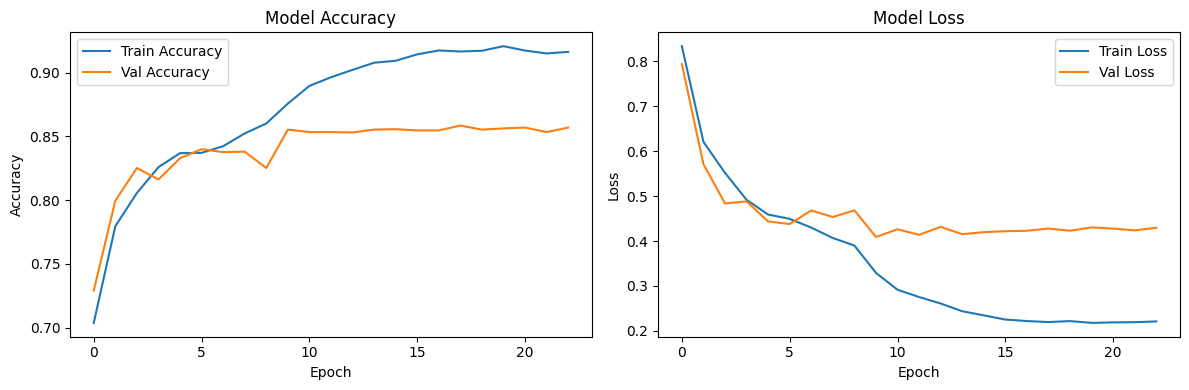

Graph saved!


In [16]:
# Training Graphs
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('training_graphs_signal.png')
plt.show()
print("Graph saved!")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

98/98 ━━━━━━━━━━━━━━━━━━━━ 18s 175ms/step


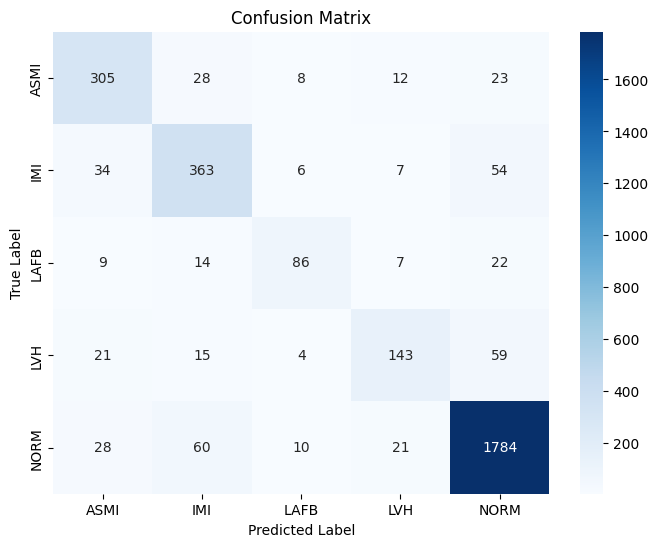

              precision    recall  f1-score   support

        ASMI       0.77      0.81      0.79       376
         IMI       0.76      0.78      0.77       464
        LAFB       0.75      0.62      0.68       138
         LVH       0.75      0.59      0.66       242
        NORM       0.92      0.94      0.93      1903

    accuracy                           0.86      3123
   macro avg       0.79      0.75      0.77      3123
weighted avg       0.86      0.86      0.86      3123



In [17]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig('confusion_matrix_signal.png')
plt.show()

print(classification_report(y_test, y_pred_classes, target_names=le.classes_))

In [18]:
model.save('ecg_signal_model.h5')
print("Model saved!")

Model saved!
